# Perceptron, Linear Regression, Logistic Regression - From Scratch & PyTorch

In this notebook we explore three core machine learning models and how they learn from data.

**🧠 Models**
1. Perceptron — simple binary classifier  
2. Linear Regression — predicts continuous values  
3. Logistic Regression — predicts probabilities for classification  

**🔁 Approach**

For each model we will:
- implement it from scratch using PyTorch tensors
- compare with `torch.nn` version
- visualize how it learns

**🔥 Core idea**

All models follow the same pattern:
> linear function + loss + gradient descent  

**🚀 Why this matters for deep learning**

These models are the foundation of neural networks. Deep learning is essentially:
> stacking many linear models with nonlinear activations and training them using the same gradient descent principle

# 🔥 1. Perceptron (first learning model)

**🧠 Intuition**

A perceptron is the simplest artificial neuron used for binary classification.

It computes:

$
z = w \cdot x + b
$

and applies a step function:

$
y =
\begin{cases}
1 & \text{if } z \ge 0 \\
0 & \text{otherwise}
\end{cases}
$

It decides:
- 0 → class A  
- 1 → class B  

---

**📜 Short history**

The perceptron was introduced by **Frank Rosenblatt in 1957** as one of the first attempts to model learning in artificial neurons. It became an early milestone in machine learning but also revealed key limitations of simple linear models.

---

**🔷 Types**

**Single-layer perceptron**
- simplest form of neural model
- linear decision boundary
- works only for linearly separable data

**Multilayer perceptron (MLP)**
- consists of multiple layers of neurons
- uses nonlinear activation functions (e.g., ReLU, sigmoid)
- can model complex nonlinear relationships

---

**⚙️ How it learns (idea)**

If the prediction is wrong, the weights are adjusted:

$
w := w + \eta (y_{true} - y_{pred}) x
$

This gradually shifts the decision boundary.

---

**📌 Where it is used**

- simple classification tasks
- as a conceptual building block for neural networks
- foundation for understanding modern deep learning models

---

**🧠 Key insight**

A perceptron is a linear classifier that separates data using a weighted sum and a threshold decision rule.

## ⚙️ Manual implementation

In [24]:
import torch

# simple dataset (AND-like problem)
X = torch.tensor([
    [0., 0.],
    [0., 1.],
    [1., 0.],
    [1., 1.]
])

y = torch.tensor([[0.], [0.], [0.], [1.]])

W = torch.randn(2, 1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

lr = 0.1

## 🔁 Training loop (manual perceptron-style)

A classical perceptron uses a step function as its activation:

$
y = step(w \cdot x + b)
$

However, this function is not differentiable, which means it cannot be trained using gradient descent and backpropagation.

Instead, in modern machine learning, we replace the step function with a smooth alternative such as the sigmoid function. This leads to logistic regression, which is fully compatible with gradient-based optimization.

In [25]:
for epoch in range(400):

    logits = X @ W + b
    preds = torch.sigmoid(logits)
    # step function not differentiable
    # preds = (logits > 0).float()

    loss = ((preds - y) ** 2).mean()

    if epoch % 50 == 0:
        print(f'{epoch} epoch loss: {loss.item()}')

    loss.backward()

    with torch.no_grad():
        W -= lr * W.grad
        b -= lr * b.grad

        W.grad.zero_()
        b.grad.zero_()

0 epoch loss: 0.26855596899986267
50 epoch loss: 0.2392662763595581
100 epoch loss: 0.21228346228599548
150 epoch loss: 0.1876213252544403
200 epoch loss: 0.16567978262901306
250 epoch loss: 0.146806001663208
300 epoch loss: 0.13099870085716248
350 epoch loss: 0.11796975880861282


In [26]:
preds

tensor([[0.1247],
        [0.4359],
        [0.1953],
        [0.5684]], grad_fn=<SigmoidBackward0>)

# 📈 2. Linear Regression

**🧠 Intuition**

Linear regression is a model used to predict continuous values.

Unlike a perceptron (which outputs classes), linear regression predicts a real number:

$
y = w \cdot x + b
$

It learns the best line (or hyperplane) that fits the data by minimizing prediction error.

---

**📜 Short idea**

Linear regression is one of the oldest and simplest machine learning models. It forms the foundation for many more complex models because it introduces the key idea:

> learning by minimizing error using gradient descent

---

**⚙️ How it works**

1. Take input features $x$
2. Compute prediction:
   $
   \hat{y} = w \cdot x + b
   $
3. Compare with true value:
   $
   loss = (\hat{y} - y)^2
   $
4. Update parameters using gradients

---

**📌 Key properties**

- outputs continuous values
- fully differentiable
- convex loss function (one global minimum)
- guaranteed convergence with proper learning rate

---

**🧠 Key insight**

Linear regression is the simplest example of:

> learning by fitting a line using gradient descent

## ⚙️ Manual version

In [29]:
X = torch.randn(100, 1)
true_w = 3
true_b = 2

y = true_w * X + true_b + 0.1 * torch.randn(100, 1)

W = torch.randn(1, 1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

lr = 0.1

## 🔁 Training

In [30]:
for epoch in range(100):

    y_pred = X @ W + b

    loss = ((y_pred - y) ** 2).mean()

    loss.backward()

    with torch.no_grad():
        W -= lr * W.grad
        b -= lr * b.grad

        W.grad.zero_()
        b.grad.zero_()

    if epoch % 10 == 0:
        print(f"epoch {epoch}, loss = {loss.item():.4f}")

epoch 0, loss = 19.6755
epoch 10, loss = 0.5631
epoch 20, loss = 0.0256
epoch 30, loss = 0.0080
epoch 40, loss = 0.0074
epoch 50, loss = 0.0074
epoch 60, loss = 0.0074
epoch 70, loss = 0.0074
epoch 80, loss = 0.0074
epoch 90, loss = 0.0074


Linear regression:
- convex loss surface
- one global minimum
- gradient descent always converges

# 🔥 3. Logistic Regression

**🧠 Intuition**

Logistic regression is used for binary classification problems.

Instead of predicting a continuous value (like linear regression), it predicts a probability between 0 and 1:

$
\hat{y} = \sigma(w \cdot x + b)
$

where:

$
\sigma(z) = \frac{1}{1 + e^{-z}}
$

This outputs:
- close to 0 → class 0
- close to 1 → class 1

---

**📜 Short idea**

Logistic regression is essentially:

> linear regression + sigmoid activation + classification loss

It is one of the simplest probabilistic classifiers in machine learning.

---

**⚙️ How it works**

1. Compute linear score:
   $
   z = w \cdot x + b
   $

2. Convert to probability:
   $
   \hat{y} = \sigma(z)
   $

3. Compare with true label using binary cross entropy:
   $
   loss = -[y \log(\hat{y}) + (1 - y)\log(1 - \hat{y})]
   $

4. Update parameters using gradient descent

---

**📌 Key properties**

- outputs probabilities (0–1)
- fully differentiable
- linear decision boundary
- trained using gradient descent
- foundation of modern classification models

---

**🧠 Key insight**

Logistic regression answers:

> “What is the probability that this input belongs to class 1?”

## ⚙️ Manual implementation

In [31]:
import torch.nn.functional as F

torch.manual_seed(0)

X = torch.randn(200, 2)

true_W = torch.tensor([[2.0], [-3.0]])
true_b = torch.tensor([0.5])

logits = X @ true_W + true_b
y = (logits > 0).float()

## 🔁 Training

In [32]:
W = torch.randn(2, 1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

for epoch in range(100):

    logits = X @ W + b
    preds = torch.sigmoid(logits)

    loss = F.binary_cross_entropy(preds, y)

    loss.backward()

    with torch.no_grad():
        W -= lr * W.grad
        b -= lr * b.grad

        W.grad.zero_()
        b.grad.zero_()

    if epoch % 10 == 0:
        print(f"epoch {epoch}, loss = {loss.item():.4f}")

epoch 0, loss = 0.7187
epoch 10, loss = 0.5952
epoch 20, loss = 0.5133
epoch 30, loss = 0.4566
epoch 40, loss = 0.4151
epoch 50, loss = 0.3835
epoch 60, loss = 0.3586
epoch 70, loss = 0.3383
epoch 80, loss = 0.3214
epoch 90, loss = 0.3071


Logistic regression is a linear classifier that outputs probabilities.

It combines:
- linear model (like regression)
- sigmoid function (to map to probability)
- cross-entropy loss (for classification learning)

It is the simplest building block of modern neural networks.

# 🧠 4. Same Models using `torch.nn`

So far, we implemented models manually using tensors and gradients.

Now we will see how PyTorch simplifies everything using `torch.nn`.

The idea stays the same:
> forward pass → loss → backward pass → update weights

But PyTorch handles gradients automatically.

## 📦 Linear regression

In [33]:
import torch
import torch.nn as nn

torch.manual_seed(0)

# dataset: y = 3x + 2
X = torch.randn(100, 1)
y = 3 * X + 2 + 0.1 * torch.randn(100, 1)

model = nn.Linear(1, 1)
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

/opt/miniconda3/envs/mlpeople7/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 🔁 Training loop

In [34]:
for epoch in range(100):

    y_pred = model(X)

    loss = loss_fn(y_pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"epoch {epoch}, loss = {loss.item():.4f}")

epoch 0, loss = 10.1169
epoch 10, loss = 0.0906
epoch 20, loss = 0.0090
epoch 30, loss = 0.0084
epoch 40, loss = 0.0084
epoch 50, loss = 0.0084
epoch 60, loss = 0.0084
epoch 70, loss = 0.0084
epoch 80, loss = 0.0084
epoch 90, loss = 0.0084


nn.Linear automatically handles:
- weights (W)
- bias (b)
- forward computation
- gradient tracking

You only define:
- model
- loss
- optimizer

## 🔥 Logistic Regression (nn.Module)

In [35]:
import torch.nn.functional as F

torch.manual_seed(0)

X = torch.randn(200, 2)

true_W = torch.tensor([[2.0], [-3.0]])
true_b = torch.tensor([0.5])

y = (X @ true_W + true_b > 0).float()

model = nn.Linear(2, 1)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

### 🔁 Training loop

In [36]:
for epoch in range(100):

    logits = model(X)
    preds = torch.sigmoid(logits)

    loss = F.binary_cross_entropy(preds, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"epoch {epoch}, loss = {loss.item():.4f}")

epoch 0, loss = 0.6960
epoch 10, loss = 0.5638
epoch 20, loss = 0.4822
epoch 30, loss = 0.4282
epoch 40, loss = 0.3901
epoch 50, loss = 0.3615
epoch 60, loss = 0.3392
epoch 70, loss = 0.3212
epoch 80, loss = 0.3063
epoch 90, loss = 0.2936


Logistic regression in PyTorch is just:

- nn.Linear (linear function)
- sigmoid (probability)
- binary cross entropy (loss)

PyTorch abstracts everything except:
👉 model structure
👉 loss function
👉 optimization step

## Comparison

Manual implementation vs `torch.nn`:

| Concept | Manual | PyTorch nn |
|--------|--------|------------|
| weights | torch tensors | nn.Linear |
| forward | explicit math | model(X) |
| gradients | loss.backward() | same |
| updates | manual SGD | optimizer.step() |

# 🧠 5. Models as `nn.Module` Classes (PyTorch Way)

So far, we used:
- manual tensor models
- `nn.Linear` directly
- simple training loops

In real PyTorch projects, models are usually defined as classes.

This gives full control over:
- architecture
- forward pass logic
- reuse and scalability

---

## 🧱 Basic structure

Every PyTorch model follows this pattern:

1. Define layers in `__init__`
2. Define computation in `forward`
3. Use `.parameters()` for training

---

## ⚙️ Example: Linear Regression as a Class

In [37]:
import torch
import torch.nn as nn

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)

### 🔁 Training loop stays the same

In [38]:
torch.manual_seed(0)

X = torch.randn(100, 1)
y = 3 * X + 2 + 0.1 * torch.randn(100, 1)

model = LinearRegressionModel()

loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

for epoch in range(100):

    y_pred = model(X)

    loss = loss_fn(y_pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"epoch {epoch}, loss = {loss.item():.4f}")

epoch 0, loss = 10.1169
epoch 10, loss = 0.0906
epoch 20, loss = 0.0090
epoch 30, loss = 0.0084
epoch 40, loss = 0.0084
epoch 50, loss = 0.0084
epoch 60, loss = 0.0084
epoch 70, loss = 0.0084
epoch 80, loss = 0.0084
epoch 90, loss = 0.0084


**🧠 Key idea**

Using `nn.Module` means:

- you define **structure once**
- PyTorch handles gradients automatically
- training loop stays clean and reusable

---

**🔥 Why this matters**

This is the foundation of all modern deep learning models:

- CNNs
- RNNs
- Transformers

All are just:
> custom `nn.Module` classes with different `forward()` logic

# 🔥 6. Tiny Neural Network (MLP)

**🧠 Intuition**

A logistic regression model can only draw a **straight line decision boundary**.

A neural network (MLP - Multilayer Perceptron) extends this idea by adding:

- hidden layers
- nonlinear activation functions

This allows it to learn **nonlinear patterns**.

## ⚙️ Structure

A simple 2-layer MLP looks like this:

$
x → Linear → ReLU → Linear → output
$

Mathematically:

$
h = \text{ReLU}(W_1 x + b_1)
$

$
y = W_2 h + b_2
$

This is the simplest form of a neural network.

## ⚙️  Model definition

In [39]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TinyMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 8)   # hidden layer
        self.fc2 = nn.Linear(8, 1)   # output layer

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

## 🧪 Create a non-linear dataset

We need non-linear data so MLP makes sense.

In [40]:
torch.manual_seed(0)

X = torch.randn(200, 2)

# nonlinear boundary (circle-like pattern)
y = ((X[:, 0]**2 + X[:, 1]**2) < 1).float().unsqueeze(1)

## ⚙️ Training setup

In [41]:
model = TinyMLP()

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

## 🔁 Training loop

In [42]:
for epoch in range(200):

    logits = model(X)
    loss = loss_fn(logits, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        print(f"epoch {epoch}, loss = {loss.item():.4f}")

epoch 0, loss = 0.6631
epoch 20, loss = 0.6263
epoch 40, loss = 0.6027
epoch 60, loss = 0.5811
epoch 80, loss = 0.5597
epoch 100, loss = 0.5384
epoch 120, loss = 0.5178
epoch 140, loss = 0.4979
epoch 160, loss = 0.4782
epoch 180, loss = 0.4596


**What is happening here?**
- Layer 1:
    - transforms input space
    - learns intermediate features
- ReLU:
    - introduces non-linearity
    - allows bending decision boundary
- Layer 2:
    - combines learned features into final decision

A neural network is just:

> stacked linear models + nonlinear activations

Without ReLU (or similar activations), the network would still behave like a single linear model.

## MLP vs. Log Reg

In [44]:
import torch.nn as nn
import torch.nn.functional as F

log_reg = nn.Linear(2, 1)

opt1 = torch.optim.SGD(log_reg.parameters(), lr=0.1)

for _ in range(200):
    logits = log_reg(X)
    loss = F.binary_cross_entropy_with_logits(logits, y)

    opt1.zero_grad()
    loss.backward()
    opt1.step()

In [45]:
mlp = TinyMLP()
opt2 = torch.optim.SGD(mlp.parameters(), lr=0.1)

for _ in range(200):
    logits = mlp(X)
    loss = F.binary_cross_entropy_with_logits(logits, y)

    opt2.zero_grad()
    loss.backward()
    opt2.step()

### 🎨 Decision boundary visualization helper

In [47]:
import numpy as np
import matplotlib.pyplot as plt

def plot_boundary(model, title):

    x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
    y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1

    xx, yy = torch.meshgrid(
        torch.linspace(x_min, x_max, 200),
        torch.linspace(y_min, y_max, 200),
        indexing="ij"
    )

    grid = torch.cat([xx.reshape(-1,1), yy.reshape(-1,1)], dim=1)

    with torch.no_grad():
        preds = torch.sigmoid(model(grid)).reshape(xx.shape)

    plt.contourf(xx, yy, preds, levels=20, cmap="coolwarm", alpha=0.7)
    plt.scatter(X[:,0], X[:,1], c=y.squeeze(), cmap="coolwarm", edgecolor="k")
    plt.title(title)
    plt.show()

### 🔍 Visual comparison

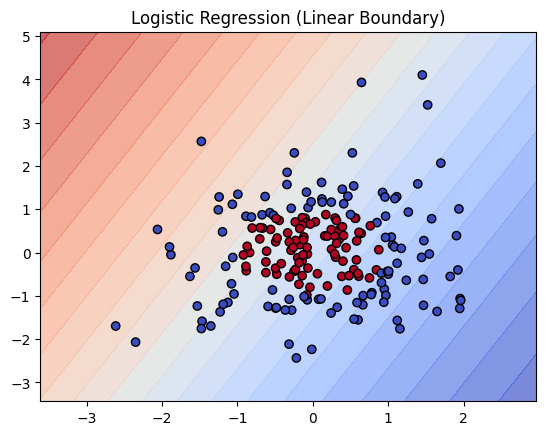

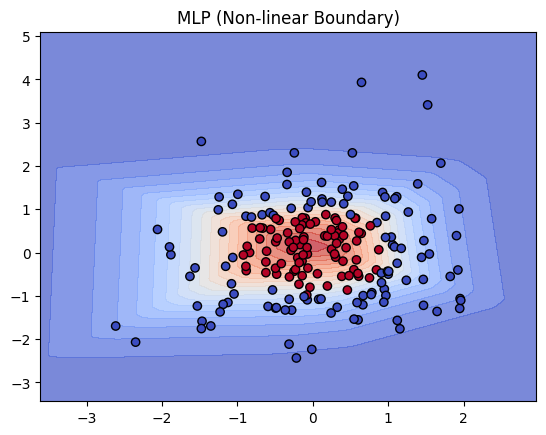

In [48]:
plot_boundary(log_reg, "Logistic Regression (Linear Boundary)")
plot_boundary(mlp, "MLP (Non-linear Boundary)")

Both models use gradient descent.

The difference is:

- Logistic Regression → linear function only
- MLP → learns intermediate representations (hidden layers)

👉 Hidden layers are what allow non-linear decision boundaries.

# 🔥 MLP vs Logistic Regression vs Perceptron

This section compares three models on the same dataset to show how their complexity affects what they can learn.

We use a simple 2D classification task and visualize how each model forms a decision boundary.

### 🧪 Dataset (non-linear problem)

We use a circular pattern so only MLP can fully solve it.

In [56]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(0)

X = torch.randn(300, 2)

# nonlinear boundary (circle)
y = ((X[:, 0]**2 + X[:, 1]**2) < 1).float().unsqueeze(1)

### ⚙️  Perceptron

In [57]:
W_p = torch.randn(2, 1)
b_p = torch.zeros(1, 1)

lr = 0.1

for _ in range(50):
    for i in range(len(X)):
        x_i = X[i:i+1]
        y_i = y[i:i+1]

        pred = (x_i @ W_p + b_p > 0).float()
        error = y_i - pred

        W_p += lr * error * x_i.T
        b_p += lr * error

### ⚙️ Logistic Regression

In [58]:
import torch.nn.functional as F

W_l = torch.randn(2, 1, requires_grad=True)
b_l = torch.zeros(1, requires_grad=True)

opt = torch.optim.SGD([W_l, b_l], lr=0.1)

for _ in range(200):
    logits = X @ W_l + b_l
    preds = torch.sigmoid(logits)

    loss = F.binary_cross_entropy(preds, y)

    opt.zero_grad()
    loss.backward()
    opt.step()

### ⚙️ MLP (Neural Network)

In [59]:
mlp = TinyMLP()
opt_mlp = torch.optim.SGD(mlp.parameters(), lr=0.1)

for _ in range(200):
    logits = mlp(X)
    loss = F.binary_cross_entropy_with_logits(logits, y)

    opt_mlp.zero_grad()
    loss.backward()
    opt_mlp.step()

### 🎨 Visualization helper

In [60]:
def plot_boundary(model_fn, title):

    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

    xx, yy = torch.meshgrid(
        torch.linspace(x_min, x_max, 200),
        torch.linspace(y_min, y_max, 200),
        indexing="ij"
    )

    grid = torch.cat([xx.reshape(-1,1), yy.reshape(-1,1)], dim=1)

    with torch.no_grad():
        preds = model_fn(grid).reshape(xx.shape)

    plt.contourf(xx, yy, preds, levels=20, cmap="coolwarm", alpha=0.7)
    plt.scatter(X[:,0], X[:,1], c=y.squeeze(), cmap="coolwarm", edgecolor="k")
    plt.title(title)
    plt.show()

### 🔍 Visual comparison

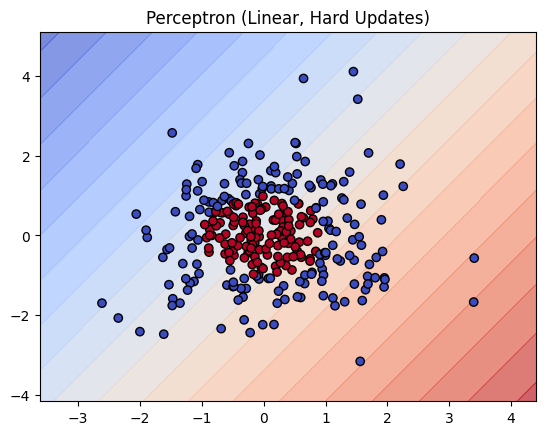

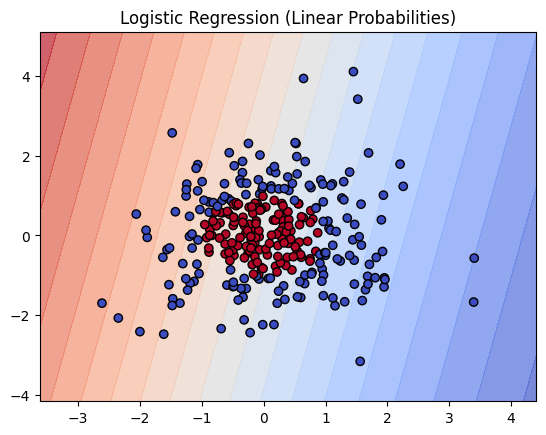

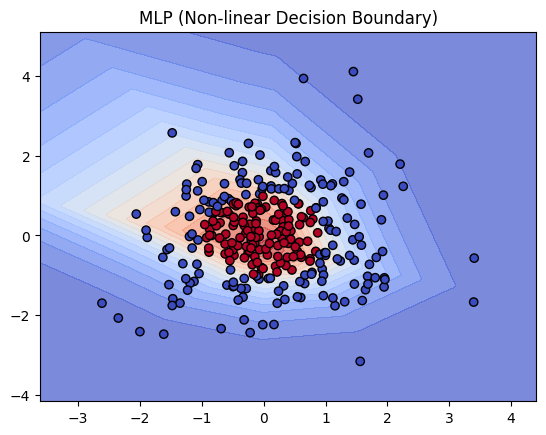

In [61]:
def perceptron_fn(grid):
    return torch.sigmoid(grid @ W_p + b_p)

plot_boundary(perceptron_fn, "Perceptron (Linear, Hard Updates)")

def logreg_fn(grid):
    return torch.sigmoid(grid @ W_l + b_l)

plot_boundary(logreg_fn, "Logistic Regression (Linear Probabilities)")

def mlp_fn(grid):
    return torch.sigmoid(mlp(grid))

plot_boundary(mlp_fn, "MLP (Non-linear Decision Boundary)")

### 🧠 Final comparison

| Model | Type | Decision Boundary | Learning |
|------|------|------------------|----------|
| Perceptron | linear | hard boundary | mistake-driven |
| Logistic Regression | linear | smooth probability | gradient descent |
| MLP | nonlinear | flexible curved boundary | deep gradient descent |


**🔥 Core insight**
- Perceptron → draws a line, corrects mistakes
- Logistic Regression → draws a line, learns probabilities
- MLP → bends space so complex patterns become linear